# Prompt Variations

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import torch
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from pathlib import Path
from functools import partial

from monoculture.analysis.setup import (
    variations,
    map_short_to_feature_order,
    map_feature_order_to_short,
)

from monoculture.analysis.utils import (
    create_result_df,
    key_to_model,
    get_metric,
    get_predictions,
    prettify_model_name,
    is_instruction_tuned,
    truncate,
    load_risk_scores,
    get_size_and_it,
)

plot_config_file = "./results/.matplotlibrc"
# plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

In [3]:
# plot_config_file = "./results/.matplotlibrc"
# plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = [
    "ACSIncome",
]
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_variations.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/"

subfolder = [
    "folktexts/0-variations",
    "folktexts/10-variations",
]

data = None
variations

tasks ['ACSIncome']


{'format': ['bullet', 'text', 'comma'],
 'connector': ['is', '=', ':'],
 'granularity': ['original', 'low'],
 'feature_order': ['default', 'rand 1', 'rand 2', 'rand 3', ' reversed']}

## Load available models and variations

In [4]:
load_df = False
df = (
    pd.read_csv(results_df_path)
    if load_df
    else create_result_df(
        RESULTS_ROOT_DIR, subfolders=subfolder, tasks=TASKS, save_path=results_df_path
    )
)

Shape of df:  (1097, 14)
Saving dataframe to results/overview_results_variations.csv


In [16]:
num_shots = 0
threshold_fitted = 0

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_vary_prompt = df[
    (df["num_shots"] == num_shots) & (df["threshold_fitted"] == threshold_fitted)
]
print(df_vary_prompt.shape)
df_vary_prompt.head()

(181, 14)


,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
77,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.609649,3994219878,0,comma,is,original,rand 1,results/folktexts/0-variations/model-meta-llam...,results/folktexts/0-variations/model-meta-llam...
80,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.625780,950682233,0,bullet,:,original,rand 3,results/folktexts/0-variations/model-meta-llam...,results/folktexts/0-variations/model-meta-llam...
82,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.684548,2729434647,0,comma,is,low,rand 3,results/folktexts/0-variations/model-meta-llam...,results/folktexts/0-variations/model-meta-llam...
83,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.572478,80916486,0,comma,:,original,reversed,results/folktexts/0-variations/model-meta-llam...,results/folktexts/0-variations/model-meta-llam...
85,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.621947,856629311,0,text,is,low,rand 1,results/folktexts/0-variations/model-meta-llam...,results/folktexts/0-variations/model-meta-llam...


## Load predictions

In [17]:
risk_scores = (
    df_vary_prompt["predictions_path"]
    .apply(load_risk_scores)
    .apply(lambda x: x.squeeze())
    .add_prefix("score_")
)
risk_scores.head()
df_with_riskscores = pd.concat([df_vary_prompt, risk_scores], axis=1)
print(df_with_riskscores.shape)
df_with_riskscores.head()

(181, 166464)


,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,score_944636,score_675237,score_926337,score_2205318,score_3164791,score_43637,score_2494279,score_2989522,score_688458,score_1778641
77,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.609649,3994219878,0,comma,is,...,0.957889,0.000405,0.997009,0.924173,0.987568,0.990274,0.053397,0.407407,0.984055,0.974001
80,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.625780,950682233,0,bullet,:,...,0.914968,0.000123,0.997951,0.946557,0.987532,0.991421,0.025899,0.468254,0.990321,0.985950
82,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.684548,2729434647,0,comma,is,...,0.962556,0.000405,0.992403,0.852000,0.531187,0.967011,0.012444,0.041988,0.992433,0.990306
83,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.572478,80916486,0,comma,:,...,0.970584,0.001246,0.998075,0.966870,0.992407,0.991922,0.222930,0.678261,0.989647,0.990878
85,ACSIncome,meta-llama--Meta-Llama-3-8B-Instruct,1,0,0.5,0.621947,856629311,0,text,is,...,0.974052,0.000519,0.991958,0.880808,0.892911,0.974099,0.164790,0.018015,0.996623,0.992403


In [18]:
df_with_predictions = df_with_riskscores.copy()
model_wise_thresholds = df_with_predictions["threshold"]
df_with_predictions.update(
    df_with_predictions.filter(like="score_").apply(
        lambda col: (col >= model_wise_thresholds).astype(int)
    )
)

## Aggregate Level: Check accuracy

Accuracy for one variation, averaging over the other. 

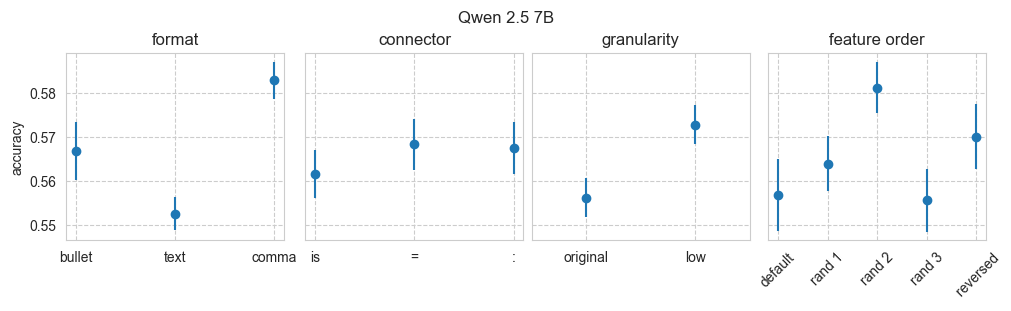

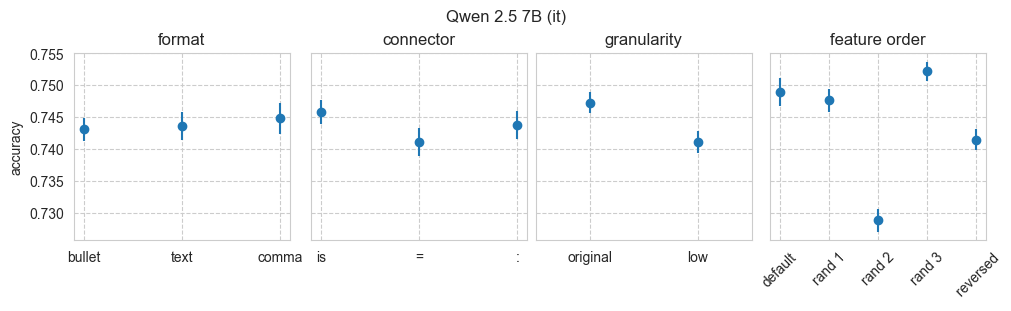

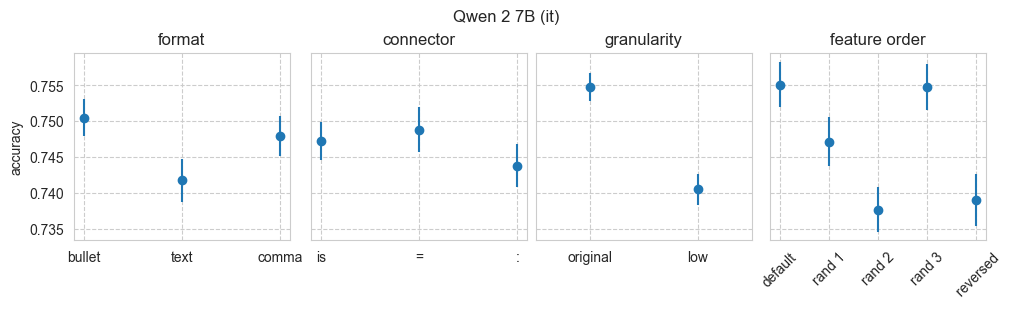

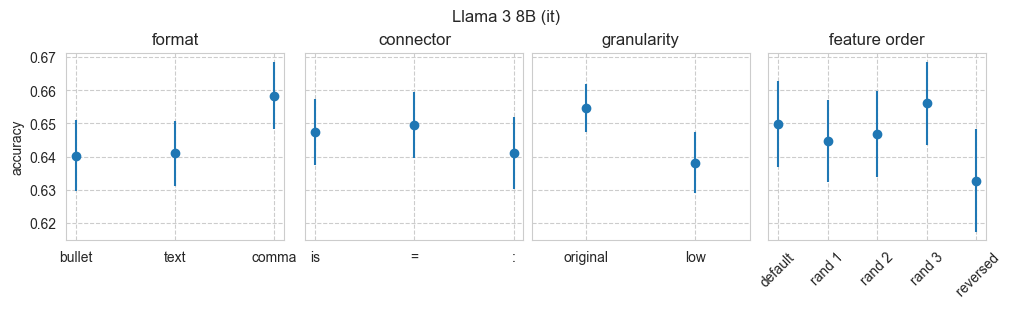

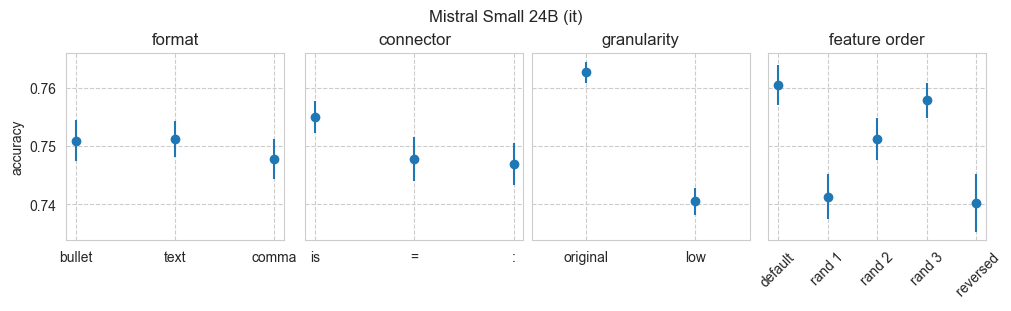

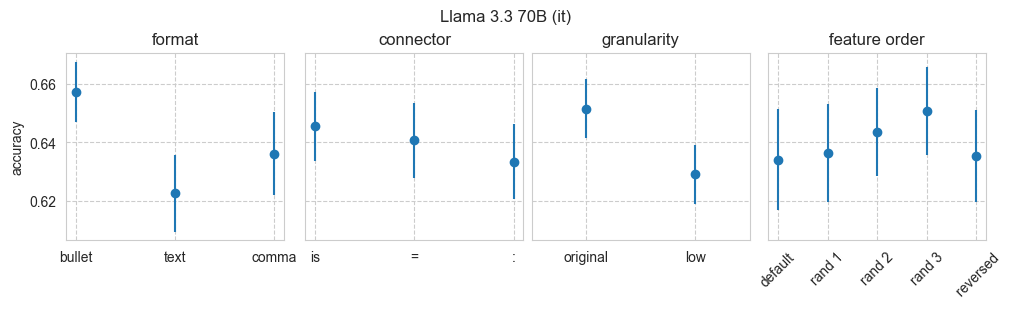

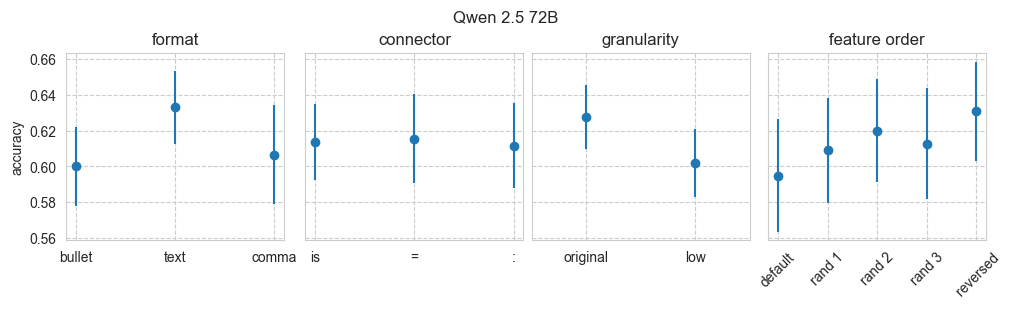

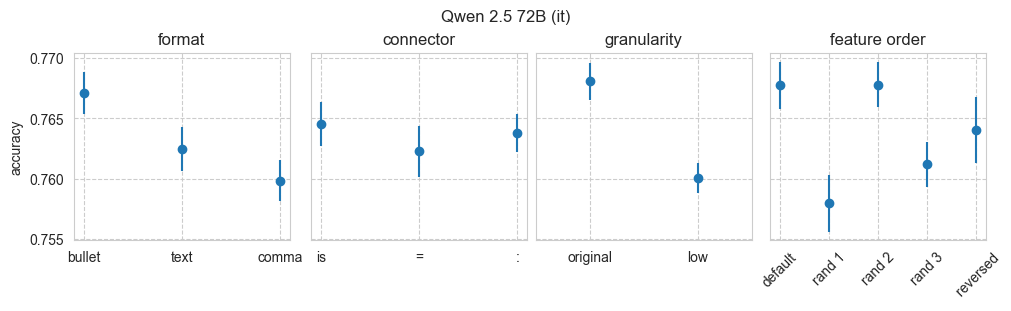

In [19]:
models = df["model"].unique()
for model in sorted(models, key=get_size_and_it):
    fig, axs = plt.subplots(
        1,
        len(variations.keys()),
        figsize=(10, 3),
        constrained_layout=True,
        sharey=True,
        sharex="col",
    )
    for i, (vary_variable, vary_values) in enumerate(variations.items()):
        # print(vary_variable, vary_values)
        num_vals = len(vary_values)
        mean_per_val = []
        std_err_per_val = []
        for val in vary_values:
            accs = df[(df["model"] == model) & (df["prompt_" + vary_variable] == val)][
                "accuracy"
            ].values
            mean_per_val.append(accs.mean())
            std_err_per_val.append(accs.std() / np.sqrt(len(accs)))
        axs[i].errorbar(
            np.arange(num_vals), mean_per_val, yerr=std_err_per_val, fmt="o"
        )
        # axs[i,i].errorbar(x=np.arange(len(variations[vari])), y=mean_per_val, yerr=stderr_per_val, fmt='o', color='black')
        axs[i].set_xticks(
            np.arange(num_vals),
            vary_values,
            rotation=(0 if vary_variable != "feature_order" else 45),
            ha="center",
        )
        axs[i].set_title(vary_variable.replace("_", " "))
        if num_vals <= 2:
            axs[i].set_xmargin(0.5)

    axs[0].set_ylabel("accuracy")
    fig.suptitle(prettify_model_name(key_to_model(model)))

    file_name = "".join(
        [
            f"model-{model}-{num_shots}-shot-accuracy-fix-one-avg-rest",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            ".png",
        ]
    )
    plt.savefig(FIGURES_ROOT_DIR/'paper'/'vary-prompt'/file_name)

    plt.show()

Matrix Plot: accuracy for pairs of variations, averaging over the rest. 

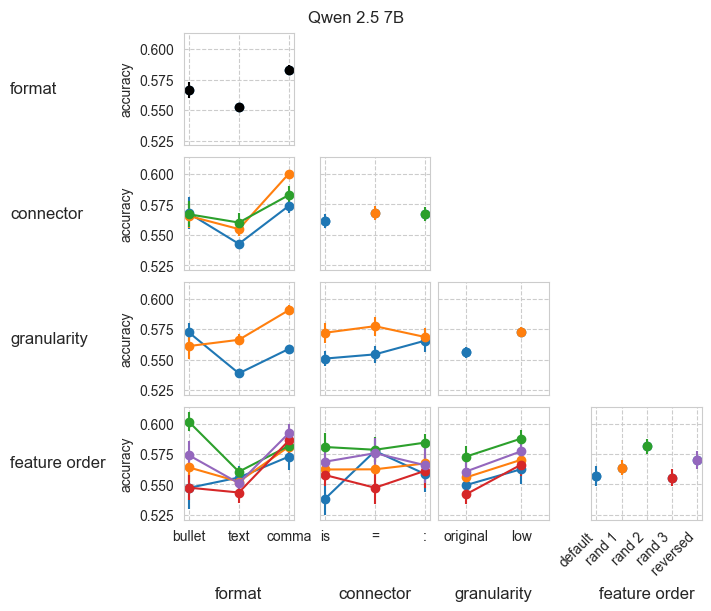

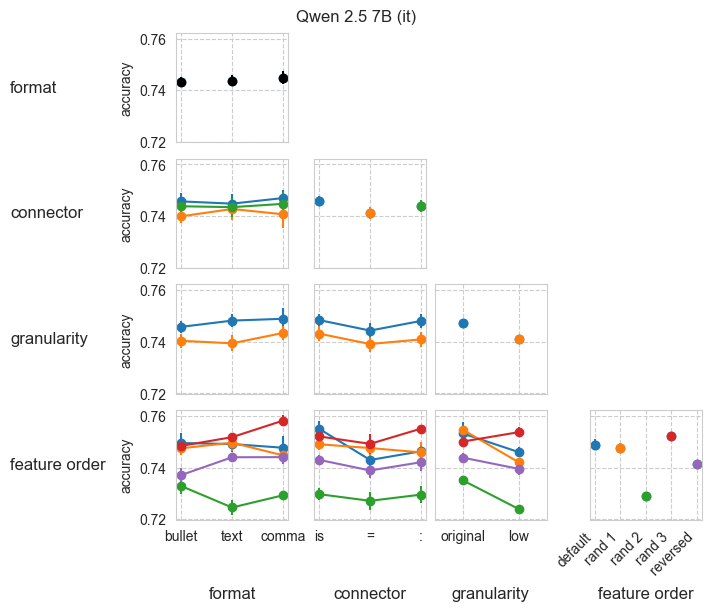

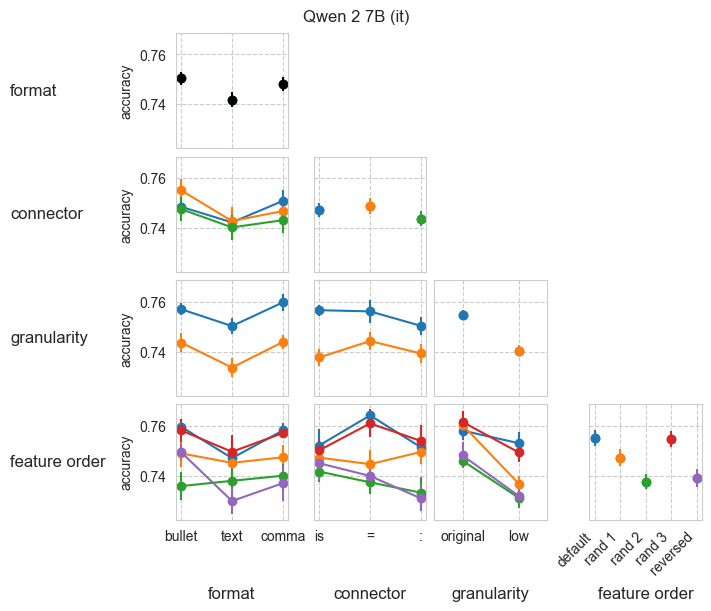

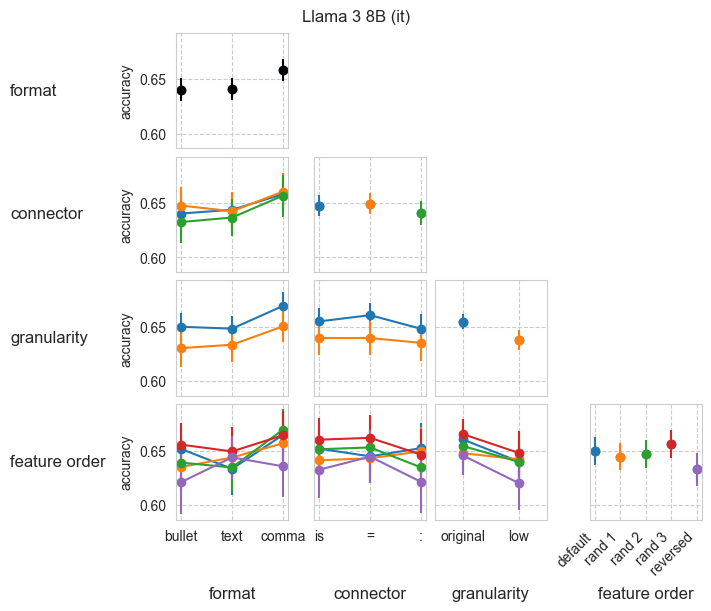

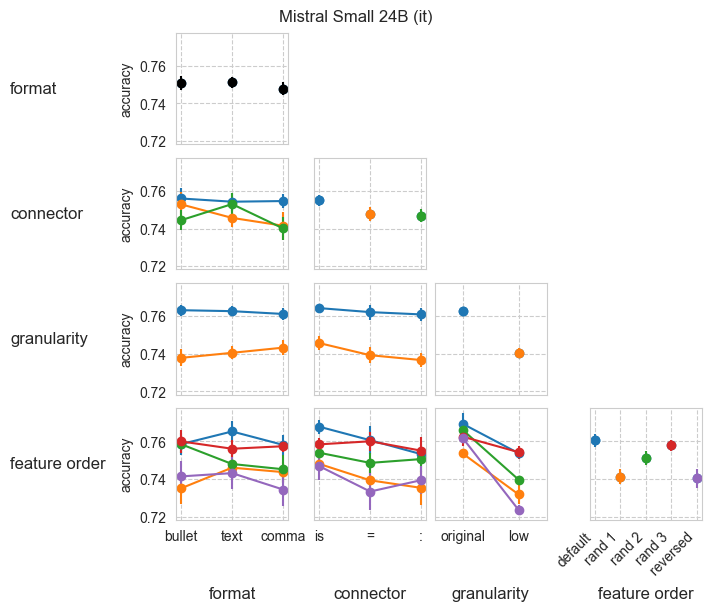

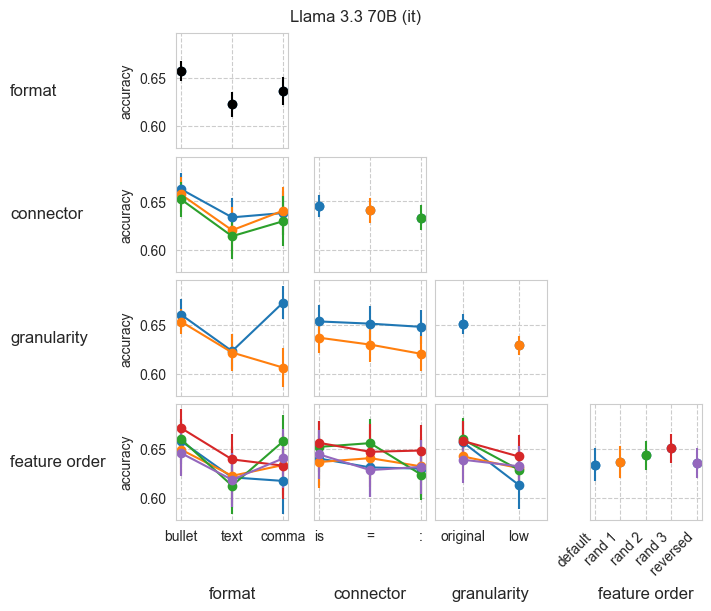

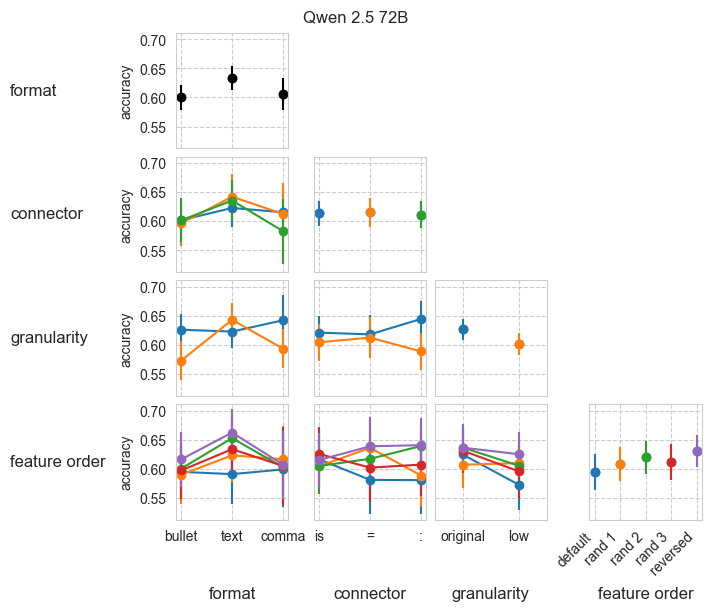

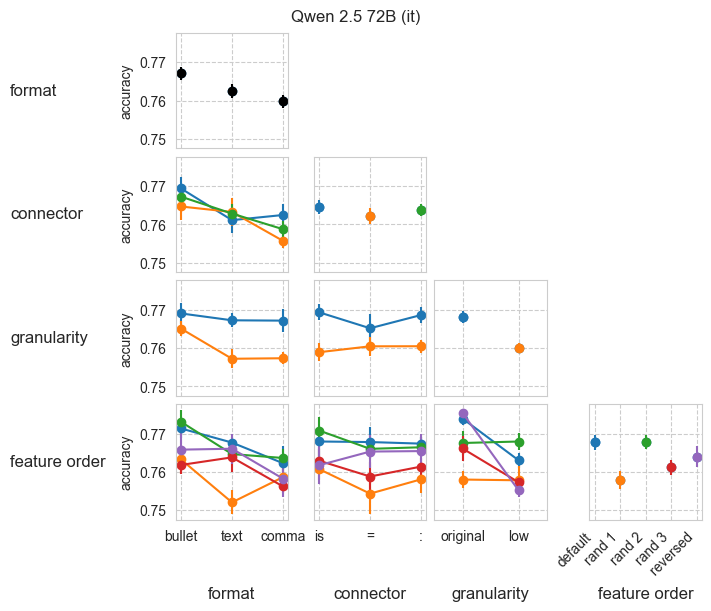

In [20]:
# lower triangular
for model in sorted(models, key=get_size_and_it):
    fig, axs = plt.subplots(
        len(variations.keys()),
        len(variations.keys()),
        figsize=(7, 6),
        constrained_layout=True,
        sharey=True,
        sharex="col",
    )
    fig.suptitle(prettify_model_name(key_to_model(model)))
    for i, vari in enumerate(variations.keys()):
        for j, varj in enumerate(variations.keys()):
            if i == j:
                mean_per_val = []
                stderr_per_val = []
                for val in variations[vari]:
                    accs = df[(df["model"] == model) & (df["prompt_" + vari] == val)][
                        "accuracy"
                    ].values
                    mean_per_val.append(accs.mean())
                    stderr_per_val.append(accs.std() / np.sqrt(len(accs)))
                axs[i, i].scatter(np.arange(len(variations[vari])), mean_per_val)
                if i > 0:  #!= len(variations.keys())-1:
                    colors = [f"C{i}" for i in range(len(mean_per_val))]
                    for idx, (x_val, y_val, yerr_val) in enumerate(
                        zip(np.arange(len(mean_per_val)), mean_per_val, stderr_per_val)
                    ):
                        axs[i, i].errorbar(
                            x=x_val, y=y_val, yerr=yerr_val, fmt="o", color=colors[idx]
                        )
                else:
                    axs[i, i].errorbar(
                        x=np.arange(len(variations[vari])),
                        y=mean_per_val,
                        yerr=stderr_per_val,
                        fmt="o",
                        color="black",
                    )
            elif i > j:
                # else:
                for vali in variations[vari]:
                    mean_per_valj = []
                    stderr_per_valj = []
                    for valj in variations[varj]:
                        accs = df[
                            (df["model"] == model)
                            & (df["prompt_" + vari] == vali)
                            & (df["prompt_" + varj] == valj)
                        ]["accuracy"].values
                        mean_per_valj.append(accs.mean())
                        stderr_per_valj.append(accs.std() / np.sqrt(len(accs)))
                    # axs[i,j].plot(np.arange(len(variations[varj])), mean_per_valj, label=f"{vari}={vali}")
                    # axs[i,j].scatter(np.arange(len(variations[varj])), mean_per_valj, label=f"{vari}={vali}")
                    axs[i, j].errorbar(
                        x=np.arange(len(variations[varj])),
                        y=mean_per_valj,
                        yerr=stderr_per_valj,
                        fmt="-o",
                        label=f"{vari}={vali}",
                    )
            else:
                axs[i, j].axis("off")
            if len(variations[varj]) <= 2:
                axs[i, j].set_xmargin(0.5)
            if i == len(variations.keys()) - 1:
                axs[i, j].set_xticks(
                    np.arange(len(variations[varj])),
                    variations[varj],
                    rotation=0 if varj != "feature_order" else 45,
                    ha="center" if varj != "feature_order" else "right",
                )
                axs[i, j].set_xlabel(varj.replace("_", " "), size="large")
            if j == 0:
                axs[i, j].set_ylabel("accuracy")
                axs[i, j].annotate(
                    vari.replace("_", " "),
                    xy=(0, 0.5),
                    xytext=(-axs[i, j].yaxis.labelpad - 75, 0),
                    xycoords=axs[i, j].yaxis.label,
                    textcoords="offset points",
                    size="large",
                    ha="left",
                    va="center",
                )

    fig.align_xlabels()

    file_name = "".join(
        [
            f"model-{model}-{num_shots}-shot-accuracy-matrix",
            "_tresh_fitted" if threshold_fitted == 1 else "",
            ".png",
        ]
    )
    plt.show()

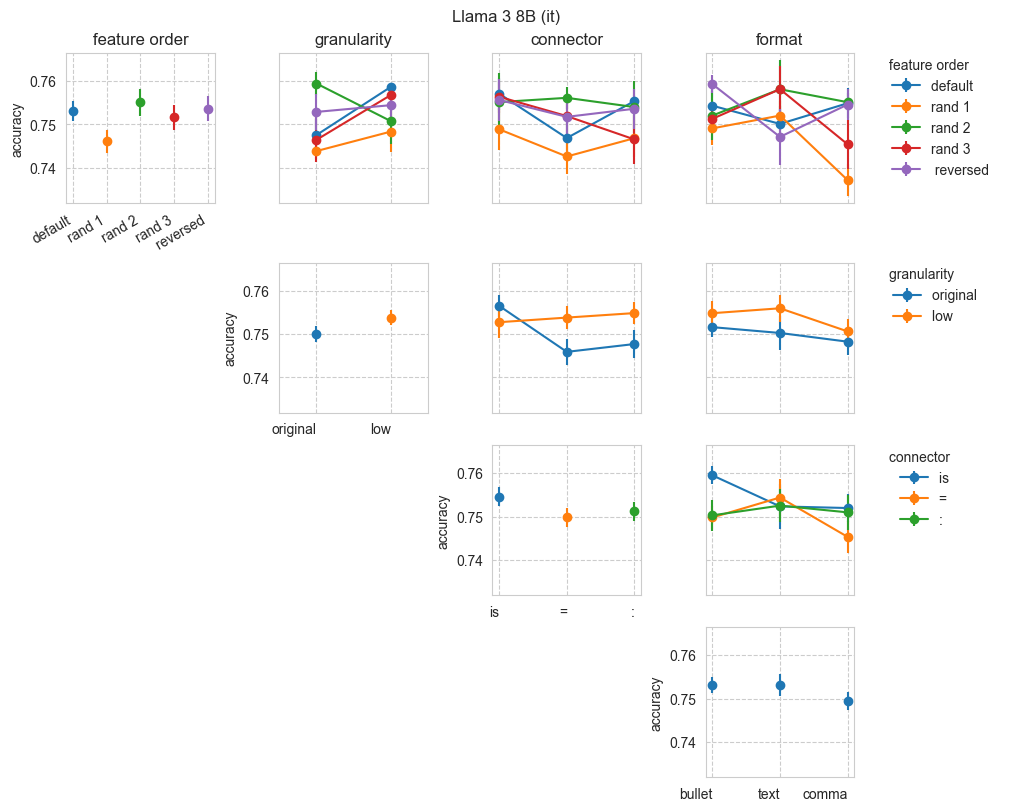

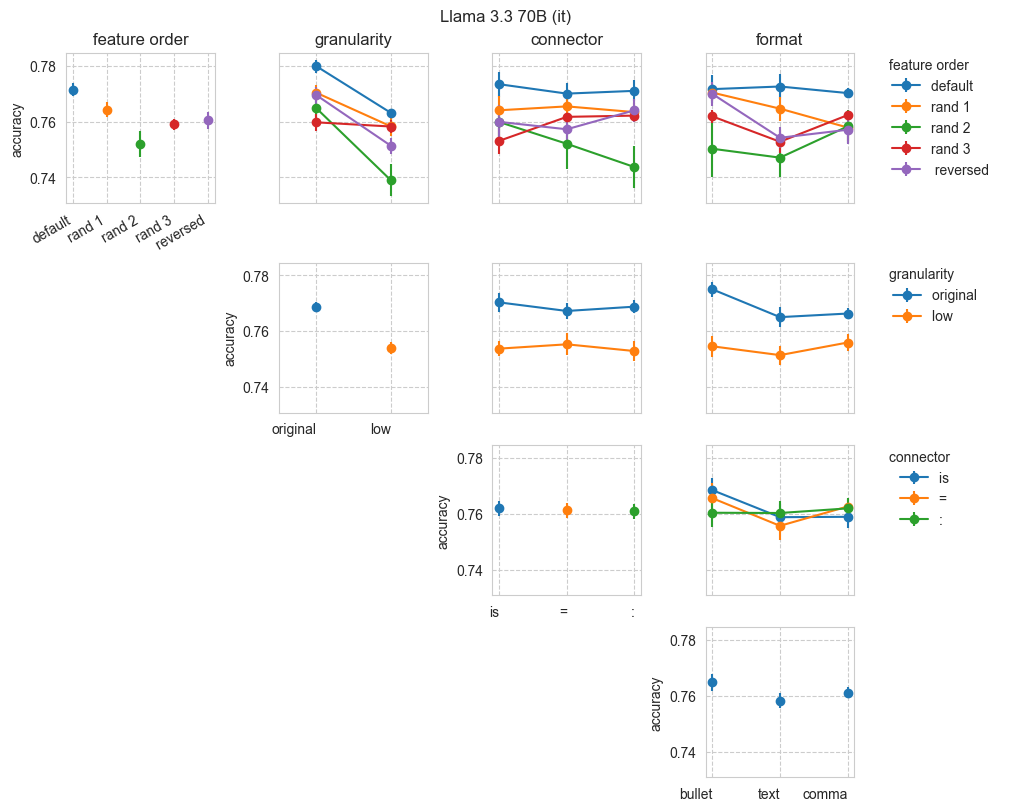

In [ ]:
# upper triangular
for model in models:
    fig, axs = plt.subplots(
        len(variations.keys()),
        len(variations.keys()),
        figsize=(10, 8),
        constrained_layout=True,
        sharey=True,
        sharex="col",
    )
    fig.suptitle(prettify_model_name(key_to_model(model)))
    for i, vari in enumerate(list(variations.keys())[::-1]):
        for j, varj in enumerate(list(variations.keys())[::-1]):
            if i == j:
                mean_per_val = []
                stderr_per_val = []
                for val in variations[vari]:
                    accs = df[(df["model"] == model) & (df["prompt_" + vari] == val)][
                        "accuracy"
                    ].values
                    mean_per_val.append(accs.mean())
                    stderr_per_val.append(accs.std() / np.sqrt(len(accs)))
                # axs[i,i].scatter(np.arange(len(variations[vari])), mean_per_val)
                if i != len(variations.keys()) - 1:
                    colors = [f"C{i}" for i in range(len(mean_per_val))]
                    for idx, (x_val, y_val, yerr_val) in enumerate(
                        zip(np.arange(len(mean_per_val)), mean_per_val, stderr_per_val)
                    ):
                        axs[i, i].errorbar(
                            x=x_val, y=y_val, yerr=yerr_val, fmt="o", color=colors[idx]
                        )
                else:
                    axs[i, i].errorbar(
                        x=np.arange(len(variations[vari])),
                        y=mean_per_val,
                        yerr=stderr_per_val,
                        fmt="o",
                        color="C0",
                    )
            elif i < j:
                # else:
                for vali in variations[vari]:
                    mean_per_valj = []
                    stderr_per_valj = []
                    for valj in variations[varj]:
                        accs = df[
                            (df["model"] == model)
                            & (df["prompt_" + vari] == vali)
                            & (df["prompt_" + varj] == valj)
                        ]["accuracy"].values
                        mean_per_valj.append(accs.mean())
                        stderr_per_valj.append(accs.std() / np.sqrt(len(accs)))
                    # axs[i,j].plot(np.arange(len(variations[varj])), mean_per_valj, label=f"{vari}={vali}")
                    # axs[i,j].scatter(np.arange(len(variations[varj])), mean_per_valj, label=f"{vari}={vali}")
                    axs[i, j].errorbar(
                        x=np.arange(len(variations[varj])),
                        y=mean_per_valj,
                        yerr=stderr_per_valj,
                        fmt="-o",
                        label=vali,
                    )
            else:
                axs[i, j].axis("off")
            axs[i, j].set_xticks(
                np.arange(len(variations[varj])),
                variations[varj],
                rotation=0 if varj != "feature_order" else 30,
                ha="right",
            )
            if len(variations[varj]) <= 2:
                axs[i, j].set_xmargin(0.5)
            if i == j:
                # axs[i,j].set_xlabel(varj.replace("_", " "))
                axs[i, j].tick_params(labelleft=True, labelbottom=True)
                axs[i, j].set_ylabel("accuracy")
            if i == 0:
                axs[i, j].set_title(varj.replace("_", " "))

            if j == len(variations.keys()) - 1 and i != j:
                h, l = axs[i, j].get_legend_handles_labels()
                legend = axs[i, j].legend(
                    title=f"{vari.replace('_', ' '):20}",
                    handles=h,
                    labels=[label.ljust(10, " ") for label in l],  # f"{label:12}"
                    frameon=False,
                    bbox_to_anchor=(1.15, 1.05),
                )
                legend.get_title().set_position((0, 0))

Accuracy when changing only one thing, e.g. the feature order, but keeping others fixed to default variant

In [ ]:
vary_variable = "prompt_feature_order"
default_cond = {
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
    "prompt_feature_order": variations["feature_order"][0],
}

df_vary = df.loc[
    list(
        set.intersection(
            *[
                set(df[df[key] == val].index)
                for key, val in default_cond.items()
                if key != vary_variable
            ]
        )
    )
]

prompt_format 6
Llama 3 8B (it)  	 0.75	0.01
Llama 3.3 70B (it)	 0.78	0.00
prompt_connector 6
Llama 3 8B (it)  	 0.75	0.01
Llama 3.3 70B (it)	 0.78	0.00
prompt_granularity 4
Llama 3.3 70B (it)	 0.77	0.01
Llama 3 8B (it)  	 0.76	0.00
prompt_feature_order 10
Llama 3 8B (it)  	 0.76	0.00
Llama 3.3 70B (it)	 0.78	0.00


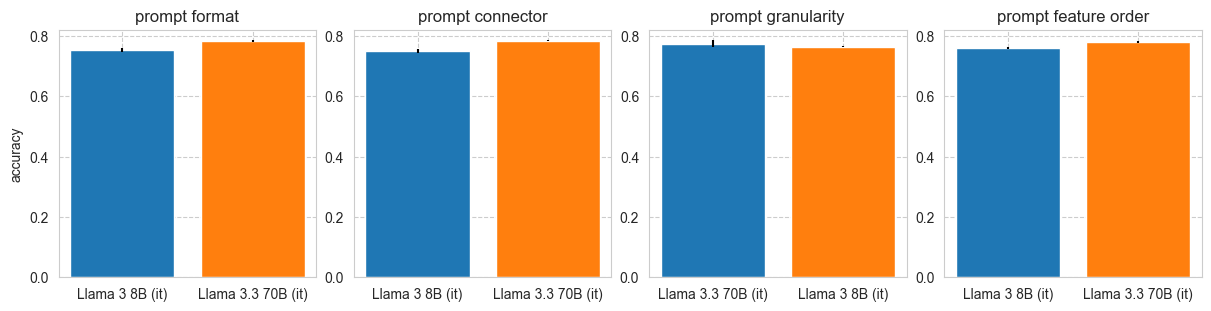

In [ ]:
vary_variable = "prompt_feature_order"
default_cond = {
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
    "prompt_feature_order": variations["feature_order"][0],
}
# df_vary = df.loc[list(set.intersection(*[set(df[df[key] == val].index) for key,val in default_cond.items() if key != vary_variable]))]

# Plot
fig, axs = plt.subplots(
    1, len(variations.keys()), figsize=(12, 3), constrained_layout=True
)
for v, vary_variable in enumerate(default_cond.keys()):
    df_vary = df.loc[
        list(
            set.intersection(
                *[
                    set(df[df[key] == val].index)
                    for key, val in default_cond.items()
                    if key != vary_variable
                ]
            )
        )
    ]
    print(vary_variable, df_vary.shape[0])
    models = df_vary["model"].unique()
    for i, model in enumerate(models):
        accs = df_vary[df_vary["model"] == model]["accuracy"].values
        mean = accs.mean()
        stderr = accs.std() / np.sqrt(len(accs))  # or standard error?
        print(
            f"{prettify_model_name(key_to_model(model)):17}\t {mean:.2f}\t{stderr:.2f}"
        )

        # axs[v].errorbar(i, mean, yerr=stderr, fmt='o')#
        axs[v].bar(i, mean, yerr=stderr, label=prettify_model_name(key_to_model(model)))
    axs[v].set_xticks(
        np.arange(len(models)),
        [prettify_model_name(key_to_model(model)) for model in models],
    )  # , rotation=45)
    axs[v].set_title(vary_variable.replace("_", " "))
    axs[v].set_ylim(0.0, 0.82)
    # axs[v].set_xmargin(0.5)
axs[0].set_ylabel("accuracy")
plt.show()

prompt_format 6
Llama 3 8B (it)  	 0.75	0.01
Llama 3.3 70B (it)	 0.78	0.00
prompt_connector 6
Llama 3 8B (it)  	 0.75	0.01
Llama 3.3 70B (it)	 0.78	0.00
prompt_granularity 4
Llama 3 8B (it)  	 0.76	0.00
Llama 3.3 70B (it)	 0.77	0.01
prompt_feature_order 10
Llama 3 8B (it)  	 0.76	0.00
Llama 3.3 70B (it)	 0.78	0.00


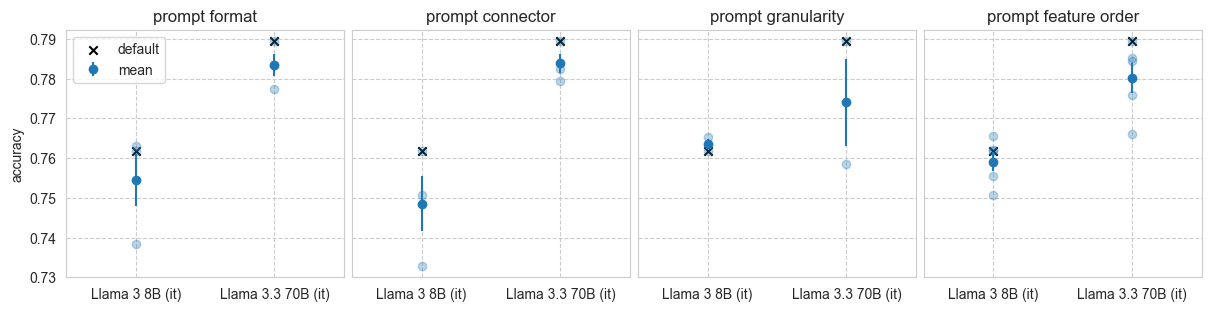

In [ ]:
vary_variable = "prompt_feature_order"
default_cond = {
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
    "prompt_feature_order": variations["feature_order"][0],
}
# df_vary = df.loc[list(set.intersection(*[set(df[df[key] == val].index) for key,val in default_cond.items() if key != vary_variable]))]

# Plot
fig, axs = plt.subplots(
    1, len(variations.keys()), figsize=(12, 3), constrained_layout=True, sharey=True
)
for v, vary_variable in enumerate(default_cond.keys()):
    df_vary = df.loc[
        list(
            set.intersection(
                *[
                    set(df[df[key] == val].index)
                    for key, val in default_cond.items()
                    if key != vary_variable
                ]
            )
        )
    ]
    print(vary_variable, df_vary.shape[0])
    models = sorted(df_vary["model"].unique())
    for i, model in enumerate(models):
        reference_acc = df.loc[
            list(
                set.intersection(
                    *[
                        set(df[df[key] == val].index)
                        for key, val in default_cond.items()
                    ],
                    df[df["model"] == model].index,
                )
            )
        ]["accuracy"].item()
        accs = df_vary[df_vary["model"] == model]["accuracy"].values
        mean = accs.mean()
        stderr = accs.std() / np.sqrt(len(accs))  # or standard error?
        print(
            f"{prettify_model_name(key_to_model(model)):17}\t {mean:.2f}\t{stderr:.2f}"
        )
        axs[v].scatter(i, reference_acc, color="black", marker="x", label="default")
        axs[v].errorbar(i, mean, yerr=stderr, fmt="o", color="C0", label="mean")
        axs[v].scatter([i] * len(accs), accs, color="C0", alpha=0.3)
    axs[v].set_xticks(
        np.arange(len(models)),
        [prettify_model_name(key_to_model(model)) for model in models],
    )  # , rotation=45)
    axs[v].set_title(vary_variable.replace("_", " "))
    axs[v].set_xmargin(0.5)
axs[0].set_ylabel("accuracy")
handles, labels = axs[0].get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
axs[0].legend(unique_labels.values(), unique_labels.keys())
plt.show()

## Individual Level: How much does the model agree given different prompts?

In [ ]:
from monoculture.analysis.utils import get_size_and_it
from monoculture.analysis.metrics import (
    matrix_pairwise_evals,
    expected_pairwise_agreement,
    get_observed_pairwise_agreement,
)


def observed_agreement_wrapper(
    m1: str, m2: str, predictions: pd.DataFrame, fun=get_observed_pairwise_agreement
):
    assert (m1 in predictions.columns) & (
        m2 in predictions.columns
    ), "Both models must be present as column in predictions"

    return fun(
        predictions[m1],
        predictions[m2],
    )


def agreement_line_plot(
    ax,
    agreements_observed: torch.Tensor | np.ndarray,
    agreements_exp: torch.Tensor | np.ndarray,
    sort_by=None,
    title="",
    plot_scatter=False,
):
    if isinstance(agreements_observed, torch.Tensor):
        agreements_observed = agreements_observed.numpy()
    if isinstance(agreements_exp, torch.Tensor):
        agreements_exp = agreements_exp.numpy()
    if sort_by:
        assert sort_by in [
            "observed",
            "expected",
        ], "If provided, 'sort_by' has to be one of ['observed', 'expected']."
        if sort_by == "obs":
            sort_indices = np.argsort(agreements_observed)
        elif sort_by == "exp":
            sort_indices = np.argsort(agreements_exp)
        agreements_observed = agreements_observed[sort_indices]
        agreements_exp = agreements_exp[sort_indices]
    else:
        agreements_observed = sorted(agreements_observed)
        agreements_exp = sorted(agreements_exp)

    num_model_pairs = len(agreements_observed)
    fraction_model_pairs = (
        np.arange(num_model_pairs) / (num_model_pairs - 1)
        if num_model_pairs > 1
        else np.ones((1,))
    )

    ax.plot(
        fraction_model_pairs,
        np.ones_like(agreements_observed),
        label="monoculture",
        color="red",
    )

    scatter_args = {"marker": "o", "markersize": 3} if plot_scatter else {}
    ax.plot(fraction_model_pairs, agreements_observed, label="observed", **scatter_args)
    ax.plot(fraction_model_pairs, agreements_exp, label="random error", **scatter_args)
    ax.plot(
        fraction_model_pairs,
        np.zeros_like(agreements_observed) + 0.5,
        label="chance level",
        color="grey",
        linestyle="dashed",
        linewidth=1,
        zorder=-1,
    )
    ax.fill_between(
        fraction_model_pairs,
        agreements_observed,
        np.ones_like(agreements_observed),
        color="lightgrey",
        alpha=0.4,
    )
    ax.set_ylim(bottom=0, top=1.01)
    ax.set_xlim(left=0, right=1.01)
    ax.set_title(title.replace("ACS", "ACS ").replace("_", " "))
    return ax

In [ ]:
import folktexts
from folktexts.acs import ACSTaskMetadata, ACSDataset
from folktexts.ts import TableshiftBRFSSTaskMetadata, TableshiftBRFSSDataset

from pathlib import Path
from monoculture.analysis.setup import ACS_TASKS

# Fetch ACS task and dataset
data_dir = Path("./data")
data = {}
for task in TASKS:
    if task in ACS_TASKS:
        acs_task = ACSTaskMetadata.get_task(task)
        acs_dataset_configs = folktexts.benchmark.Benchmark.ACS_DATASET_CONFIGS.copy()
        acs_dataset = ACSDataset.make_from_task(
            task=acs_task, cache_dir=data_dir, **acs_dataset_configs
        )
        X_test, y_test = acs_dataset.get_data_split("test")
        data[task] = (X_test, y_test)
    else:
        brfss_task = TableshiftBRFSSTaskMetadata.get_task(task)
        dataset_configs = (
            folktexts.benchmark.Benchmark.TABLESHIFT_DATASET_CONFIGS.copy()
        )
        ts_dataset = TableshiftBRFSSDataset.make_from_task(
            task=brfss_task, cache_dir=data_dir, **dataset_configs
        )
        X_test, y_test = ts_dataset.get_data_split("test")
        data[task] = (X_test, y_test)

In [ ]:
import scipy as sp
from monoculture.analysis.plotting import get_observed_acceptance


def plot_model_agreement_accepted(
    ax: plt.Axes,
    predictions: torch.Tensor,
    baseline_rates: torch.Tensor = None,
    y_true: torch.Tensor = None,
    restrict_only_pos_instances: bool = True,
    plot_cumulative: bool = False,
    xlabel: str = "fraction of models",
    ylabel: str = "fraction of pos. instances accepted",
    title: str = "",
    baseline_label: str = "expected",
    relative_x: bool = True,
    indicate_mean=False,
    overwrite_width=None,
):
    """
    Plots the agreement between model predictions and observed data, optionally
    comparing with a baseline.

    Parameters:
        ax: The matplotlib axis to plot on.
        predictions: A tensor of predictions from the model.
        y_true: True labels (optional).
        baseline_rates: Baseline rejection rates for comparison (optional).
        plot_cumulative: Whether to plot cumulative probabilities.
        restrict_only_pos_instances: Restrict calculation to positive instances.
        ylabel: Label for the y-axis.
        baseline_label: Label for the baseline comparison.
        relative_x: Normalize x-axis to [0, 1].

    Returns:
        ax: The matplotlib axis with the plot.
    """
    # Validate inputs
    _, M = predictions.shape
    if M == 0:
        print(ValueError("Predictions tensor is empty."))
        return ax

    # Configure the plot
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if plot_cumulative:
        ax.set_ylim(0.0, 1.02)
    # Determine x-axis scaling (width smaller than xticks)
    width = 0.08 if (1 / M > 0.08) else 0.8 * (0.08 / M)  # relative_x else 0.18
    if isinstance(overwrite_width, float):
        width = overwrite_width
    xs = torch.arange(M + 1, dtype=torch.float32)

    # Compute observed agreement
    num_models_accept, frequencies = get_observed_acceptance(
        predictions=predictions,
        restrict_only_pos_instances=restrict_only_pos_instances,
        true_labels=y_true,
        padding=True,
    )

    if relative_x:
        xs /= M
        ax.set_xlim(-0.01, 1.02 + width)

    N = frequencies.sum()

    if baseline_rates:
        # compute expected agreement
        prob_expected = torch.tensor(
            [
                sp.stats.poisson_binom.pmf(
                    k=num_accept, p=1 - np.array(baseline_rates)
                )  # baseline_rate = FNR? -> TPR = 1-FNR
                for num_accept in range(M + 1)
            ]
        )
        # plot baseline
        ax.bar(
            xs + 0.5 * width,
            prob_expected,
            width=width,
            color="C1",
            label=baseline_label,
        )
        # plot observed
        ax.bar(
            xs - 0.5 * width, frequencies / N, width=width, color="C0", label="observed"
        )
    else:
        # plot only observed
        ax.bar(xs, frequencies / N, width=width, color="C0", label="observed")

    if plot_cumulative:
        # accumulated = lambda tens: [tens[i:].sum() for i in range(len(tens))]
        ax.plot(xs, np.cumsum(frequencies / N), color="C0")
        if baseline_rates:
            ax.plot(xs, np.cumsum(prob_expected), color="C1")

    if indicate_mean:
        mean_obs = (
            frequencies.sum() / 2
        )  # (num_models_accept * frequencies).sum()/(frequencies.sum()*M)
        mean_exp = (xs * prob_expected).sum() / (prob_expected.sum())
        print(mean_obs, mean_exp)
        # ax.text(0.4, 0.1, 'aha')
        ax.text(
            mean_obs,
            ax.get_ylim()[0],
            r"$\blacktriangle$",
            color="C0",
            fontsize=12,
            ha="center",
            va="top",
            alpha=0.5,
        )
        ax.text(
            mean_exp,
            ax.get_ylim()[0],
            r"$\blacktriangle$",
            color="C1",
            fontsize=12,
            ha="center",
            va="top",
            alpha=0.5,
        )  #'▲'

    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_xlim(left=0 - 1.5 * width)
    return ax

In [ ]:
vary_variable = "prompt_feature_order"
default_cond = {
    "prompt_format": "bullet",
    "prompt_connector": "is",
    "prompt_granularity": "original",
    "prompt_feature_order": variations["feature_order"][0],
}
df_vary = df_with_predictions.loc[
    list(
        set.intersection(
            *[
                set(df_with_riskscores[df_with_riskscores[key] == val].index)
                for key, val in default_cond.items()
                if key != vary_variable
            ]
        )
    )
]
predictions = df_vary[df_vary["model"] == model].filter(like="score_")

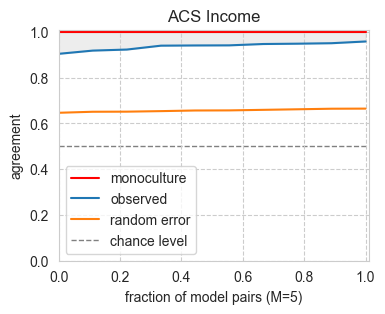

In [21]:
# agreement plot
tasks_to_plot = ["ACSIncome"]
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = predictions.transpose().columns
    M = len(models_sorted)

    # agreements without diagonal
    obs_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions.transpose()),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: expected_pairwise_agreement(
            df_vary[df_vary["model"] == model].loc[m1]["accuracy"],
            df_vary[df_vary["model"] == model].loc[m2]["accuracy"],
        ),
    ).fill_diagonal_(torch.nan)

    axs = agreement_line_plot(
        axs,
        obs_agreement_matrix[~obs_agreement_matrix.isnan()],
        exp_agreement_matrix[~exp_agreement_matrix.isnan()],
        title=task,
    )
axs.legend()
axs.set_ylabel("agreement")
axs.set_xlabel(f"fraction of model pairs (M={M})")
plt.show()

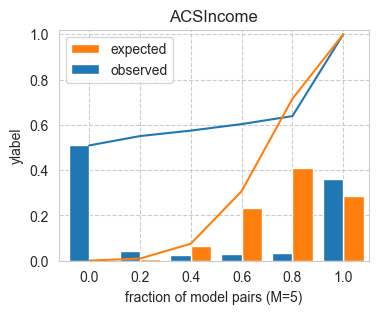

In [ ]:
# recourse plot
tasks_to_plot = ["ACSIncome"]
fig, axs = plt.subplots(1, len(tasks_to_plot), figsize=(4 * len(tasks_to_plot), 3))
sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = predictions.transpose().columns
    M = len(models_sorted)

    axs = plot_model_agreement_accepted(
        axs,
        predictions=predictions.transpose(),
        baseline_rates=list(
            df.loc[list(predictions.index)]["eval_results_path"]
            .apply(partial(get_metric, metric="fnr"))
            .values
        ),  # fn_rates,
        y_true=data[task][1],  # data,
        restrict_only_pos_instances=False,  # True
        plot_cumulative=True,
        title=task,
        ylabel="ylabel",
        xlabel=f"fraction of model pairs (M={M})",
    )
axs.legend()
plt.show()

prompt_format


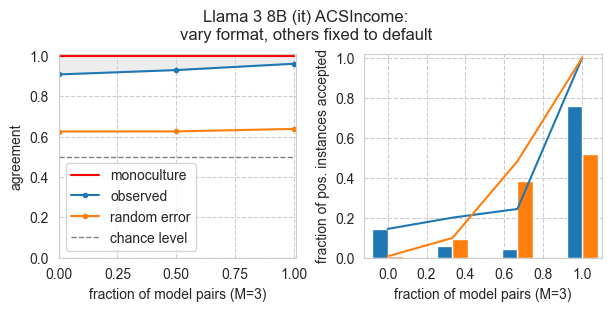

prompt_connector


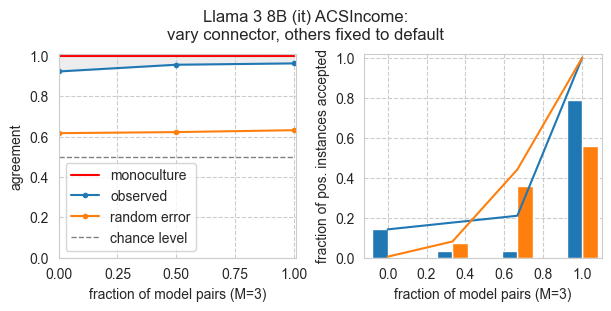

prompt_granularity


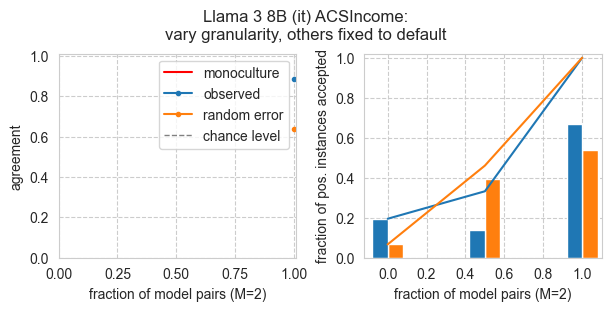

prompt_feature_order


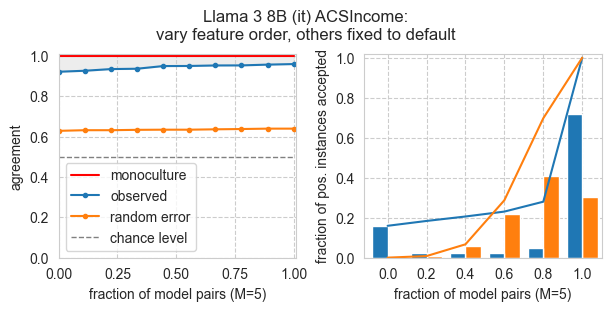

prompt_format


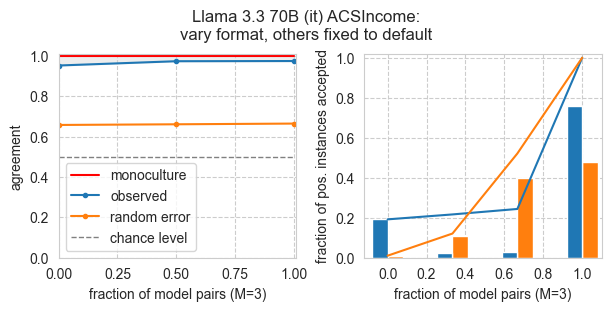

prompt_connector


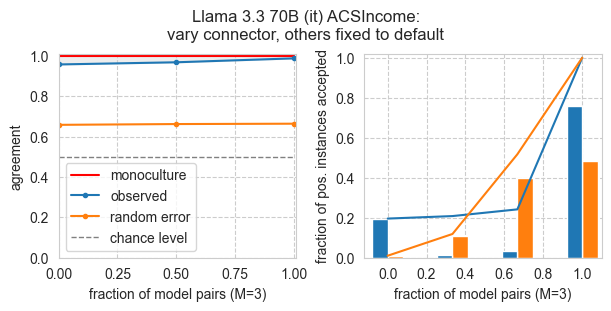

prompt_granularity


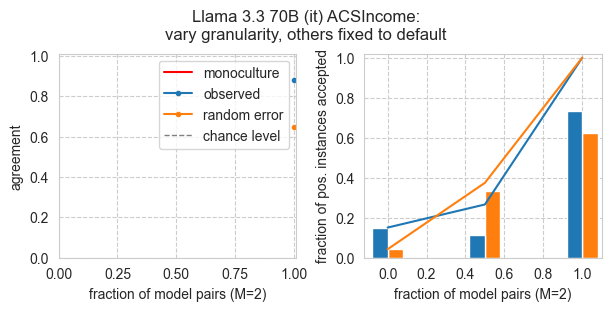

prompt_feature_order


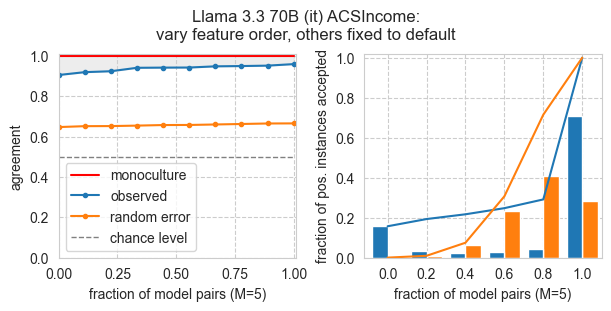

In [ ]:
tasks_to_plot = ["ACSIncome"]
sort_by = None

for task in tasks_to_plot:
    for m, model in enumerate(df_vary["model"].unique()):
        for var in default_cond.keys():
            print(var)
            fig, axs = plt.subplots(1, 2, figsize=(6, 3), constrained_layout=True)
            df_vary = df_with_predictions.loc[
                list(
                    set.intersection(
                        *[
                            set(
                                df_with_riskscores[df_with_riskscores[key] == val].index
                            )
                            for key, val in default_cond.items()
                            if key != var
                        ]
                    )
                )
            ]

            predictions = df_vary[df_vary["model"] == model].filter(like="score_")
            models_sorted = predictions.transpose().columns
            M = len(models_sorted)

            # agreements without diagonal
            obs_agreement_matrix = matrix_pairwise_evals(
                models_sorted,
                partial(
                    observed_agreement_wrapper, predictions=predictions.transpose()
                ),
            ).fill_diagonal_(torch.nan)
            exp_agreement_matrix = matrix_pairwise_evals(
                models_sorted,
                fun=lambda m1, m2: expected_pairwise_agreement(
                    df_vary[df_vary["model"] == model].loc[m1]["accuracy"],
                    df_vary[df_vary["model"] == model].loc[m2]["accuracy"],
                ),
            ).fill_diagonal_(torch.nan)

            # 2*m+0
            axs[0] = agreement_line_plot(
                axs[0],
                obs_agreement_matrix[~obs_agreement_matrix.isnan()],
                exp_agreement_matrix[~exp_agreement_matrix.isnan()],
                # title=f"{prettify_model_name(key_to_model(model))}",
                plot_scatter=True,
            )

            # 2*m+1
            axs[1] = plot_model_agreement_accepted(
                axs[1],
                predictions=predictions.transpose(),
                baseline_rates=list(
                    df.loc[list(predictions.index)]["eval_results_path"]
                    .apply(partial(get_metric, metric="fnr"))
                    .values
                ),  # fn_rates,
                y_true=data[task][1].add_prefix("score_"),  # data,
                restrict_only_pos_instances=True,  # , #True
                plot_cumulative=True,
                # title=f"{prettify_model_name(key_to_model(model))}",
                xlabel=f"fraction of model pairs (M={M})",
            )

            axs[0].legend()
            axs[0].set_ylabel("agreement")
            axs[0].set_xlabel(f"fraction of model pairs (M={M})")
            fig.suptitle(
                f"{prettify_model_name(key_to_model(model))} {task}:\nvary {var.replace('prompt_', '').replace('_', ' ')}, others fixed to default"
            )
            plt.savefig(
                f"/Users/mgorecki/Documents/projects/monoculture/results/intermediate/{prettify_model_name(key_to_model(model)).replace(' ', '_').replace('.', '_')}_vary_{var.replace('prompt_', '').replace('_', ' ')}"
            )
            plt.show()

meta-llama--Meta-Llama-3-8B-Instruct
meta-llama--Meta-Llama-3.3-70B-Instruct


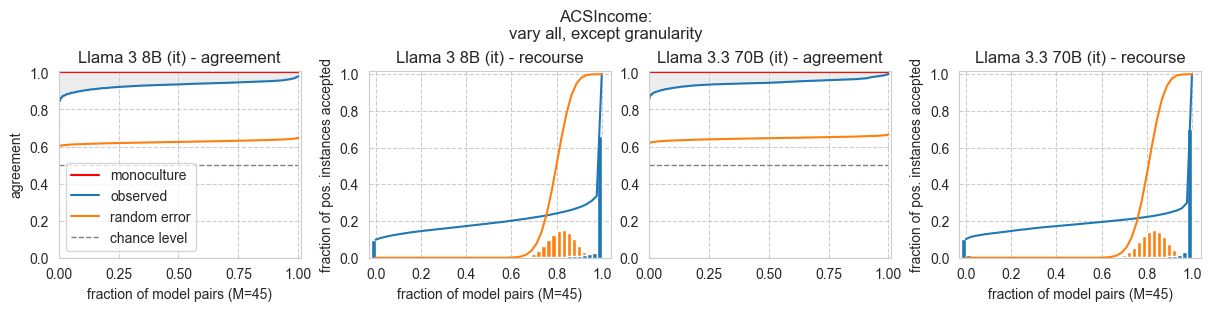

In [ ]:
tasks_to_plot = ["ACSIncome"]
sort_by = None

for task in tasks_to_plot:
    fig, axs = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)
    # only fix granularity
    df_vary_all = df_with_predictions[
        df_with_predictions["prompt_granularity"] == default_cond["prompt_granularity"]
    ]

    for m, model in enumerate(df_vary_all["model"].unique()):
        print(model)
        df_vary_all_model = df_vary_all[df_vary_all["model"] == model]
        predictions = df_vary_all_model.filter(like="score_")
        models_sorted = predictions.transpose().columns
        M = len(models_sorted)

        # agreements without diagonal
        obs_agreement_matrix = matrix_pairwise_evals(
            models_sorted,
            partial(observed_agreement_wrapper, predictions=predictions.transpose()),
        ).fill_diagonal_(torch.nan)
        exp_agreement_matrix = matrix_pairwise_evals(
            models_sorted,
            fun=lambda m1, m2: expected_pairwise_agreement(
                df_vary_all_model.loc[m1]["accuracy"],
                df_vary_all_model.loc[m2]["accuracy"],
            ),
        ).fill_diagonal_(torch.nan)

        axs[2 * m + 0] = agreement_line_plot(
            axs[2 * m + 0],
            obs_agreement_matrix[~obs_agreement_matrix.isnan()],
            exp_agreement_matrix[~exp_agreement_matrix.isnan()],
            title=f"{prettify_model_name(key_to_model(model))} - agreement",
        )

        axs[2 * m + 1] = plot_model_agreement_accepted(
            axs[2 * m + 1],
            predictions=predictions.transpose(),
            baseline_rates=list(
                df.loc[list(predictions.index)]["eval_results_path"]
                .apply(partial(get_metric, metric="fnr"))
                .values
            ),  # fn_rates,
            y_true=data[task][1].add_prefix("score_"),  # data,
            restrict_only_pos_instances=True,  # , #True
            plot_cumulative=True,
            title=f"{prettify_model_name(key_to_model(model))} - recourse",
            xlabel=f"fraction of model pairs (M={M})",
            overwrite_width=0.02,
        )

    axs[0].legend()
    axs[0].set_ylabel("agreement")
    axs[0].set_xlabel(f"fraction of model pairs (M={M})")
    fig.suptitle(f"{task}:\nvary all, except granularity")
    plt.savefig(
        f"/Users/mgorecki/Documents/projects/monoculture/results/intermediate/{prettify_model_name(key_to_model(model)).replace(' ', '_').replace('.', '_')}_vary_all"
    )
    plt.show()

## Individual Level: Recourse?